## Median house value prediction in California

## Download the data

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def fetch_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)

        with(tarfile.open(tarball_path)) as housing_tarball:
            housing_tarball.extractall(path="datasets")

    return pd.read_csv("datasets/housing/housing.csv")
housing = fetch_housing_data()
housing.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


### Description and summary of data

In [2]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Here, it's key to observe the total_bedrooms feature has only 20,433 non-null values, i.e., 207 districts are missing this feature.

In [3]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


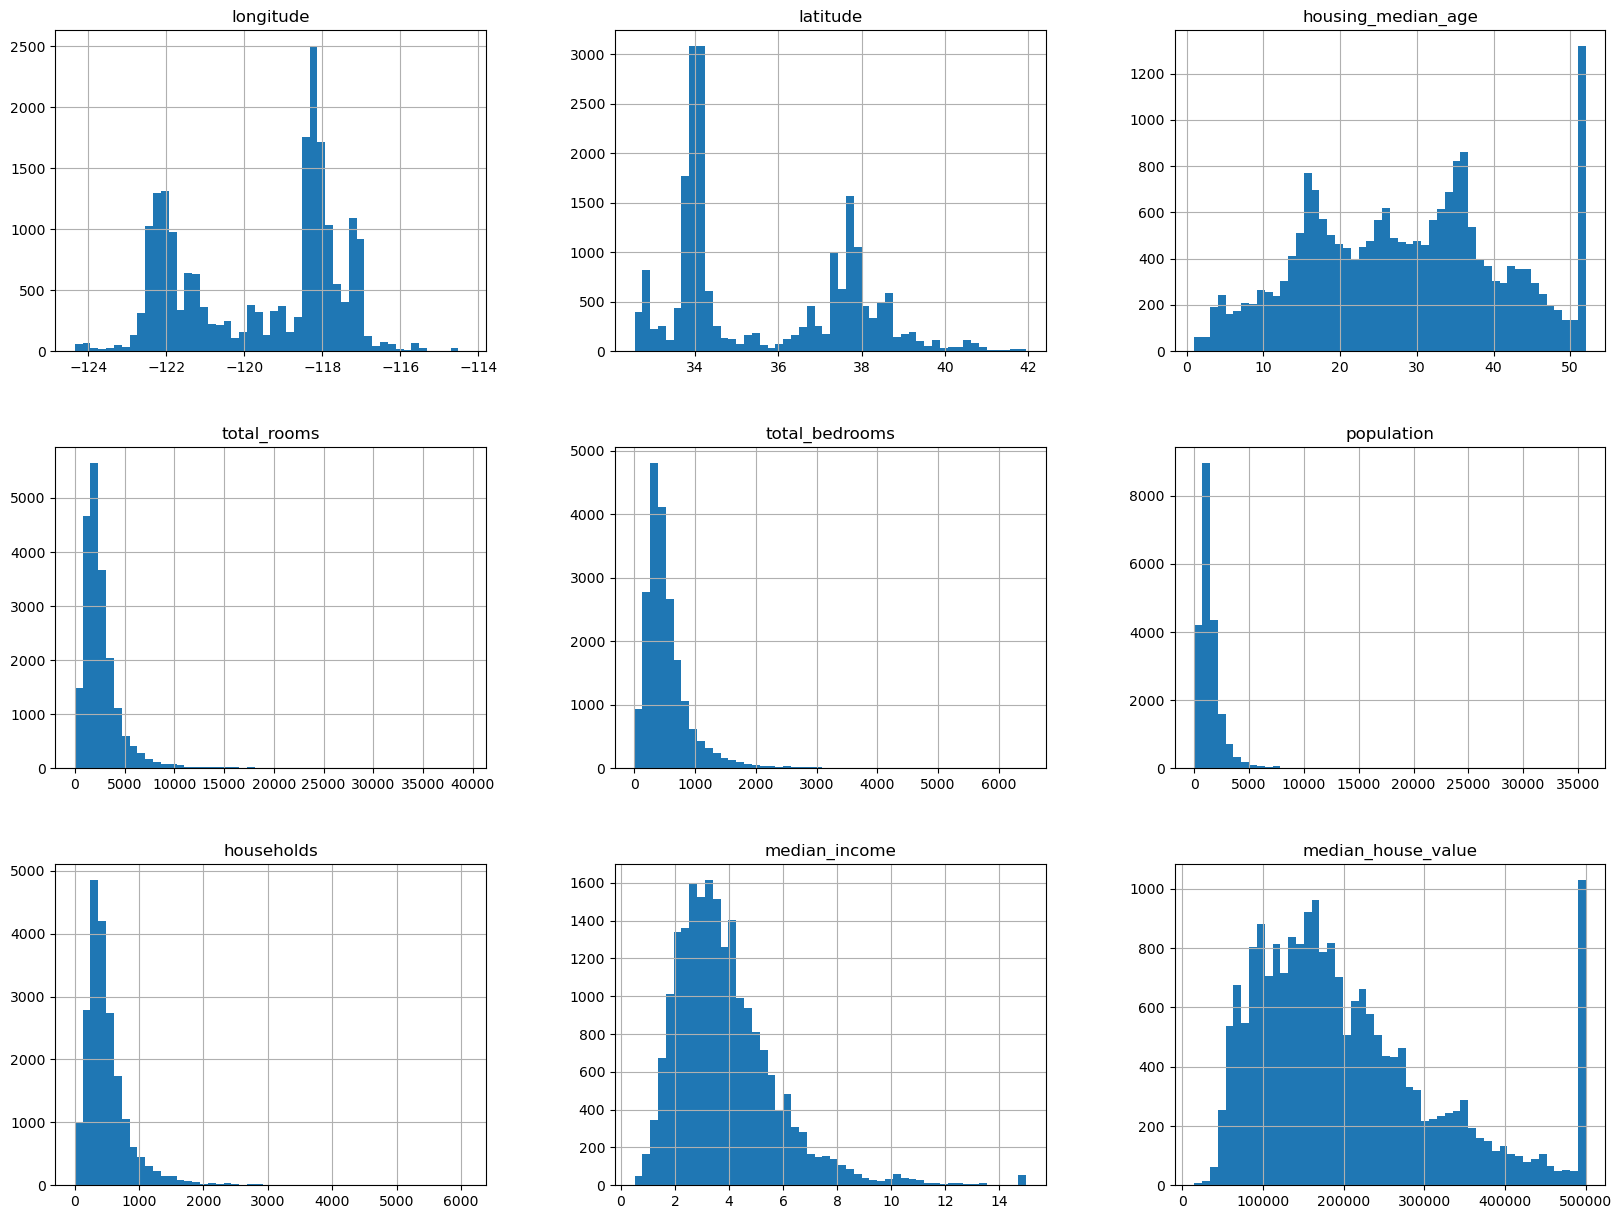

In [4]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))  
plt.show()

## Creat Test Set
1. We need the test set created to same every time we run the program, if we use np.random.permutation(len(data)) the random number generated is random and vary everytime we rerun it. That way we and the model will see the test data.

2. To solve that problem we may use random seed so we always have same train and test set, but completely random splitting is somehow skewed. For Ex. whole dataset:80% low income, 20% high income then Random test set: 95% low income, 5% high income  ❌
the model is then tested on a test set that doesn't properly represent the real data → sampling bias. To solve that isssue we use segmented groups or data chunk called strata.

3. **3.** To make the test set more representative, we use **stratified sampling**. We divide the data into meaningful groups called **strata**, such as income categories, and make sure each group is represented in the test set in roughly the same proportion as in the full dataset. This reduces the risk of **sampling bias** and gives us a test set that better represents the real dataset.

In [5]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)  # Purely random split

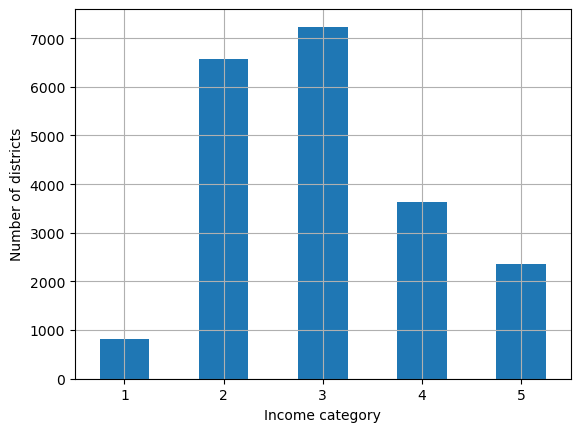

In [6]:
import numpy as np
housing["income_cat"] = pd.cut(housing["median_income"],
bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])  # Split the income into 5 categories, most important feature for price prediction

housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, 
grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42,
    stratify=housing["income_cat"]   # Income cat is median income segemented into 5 categories, so we can use it for stratified sampling.
)

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [8]:
housing = strat_train_set.copy()   # Copy so we can later return to original data

### Feature relationships
Plot latitude vs longitude (geographical location) to discover spatial pattern and identify useful relation the median price may have with those features.

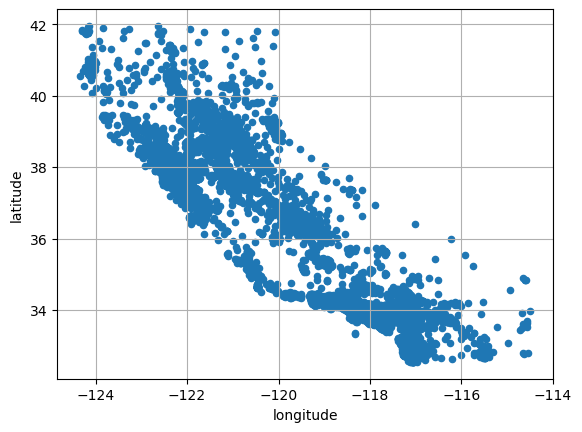

In [9]:
housing.plot(kind="scatter", x="longitude", y="latitude", 
grid=True)
plt.show()

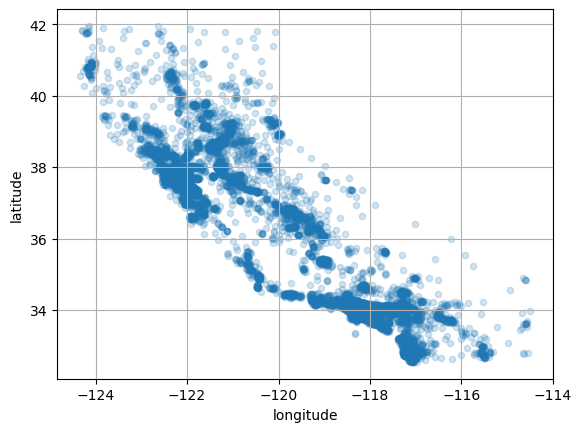

In [10]:
housing.plot(kind="scatter", x="longitude", y="latitude", 
grid=True, alpha=0.2)    # setting alpha to 0.2 makes it easier to see where the districts are densely populated
plt.show()

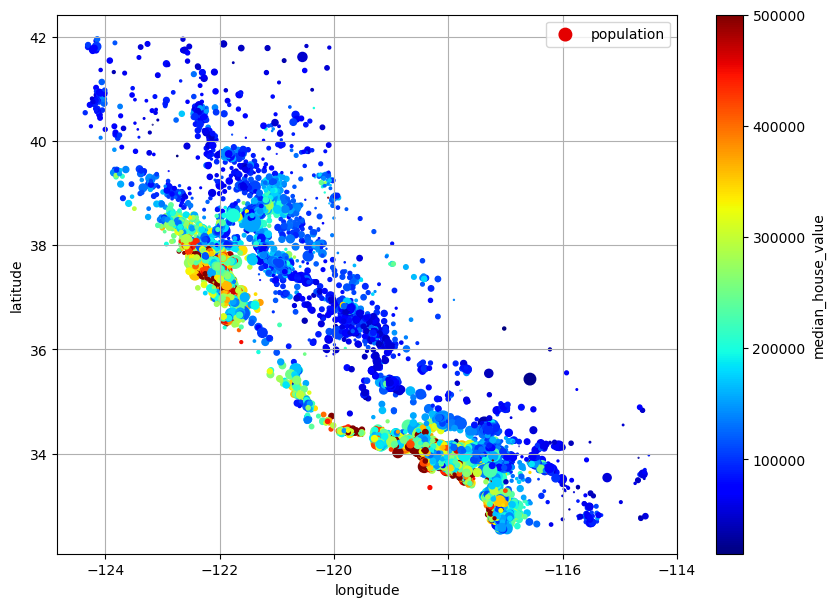

In [15]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    s=housing["population"] / 100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    legend=True,
    sharex=False,
    figsize=(10, 7)
)

plt.show()

### Correlation of each attribute with median house value

In [17]:
housing.corr(numeric_only=True)  # This will not consider the ocean proximity since it is a categorical column.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000


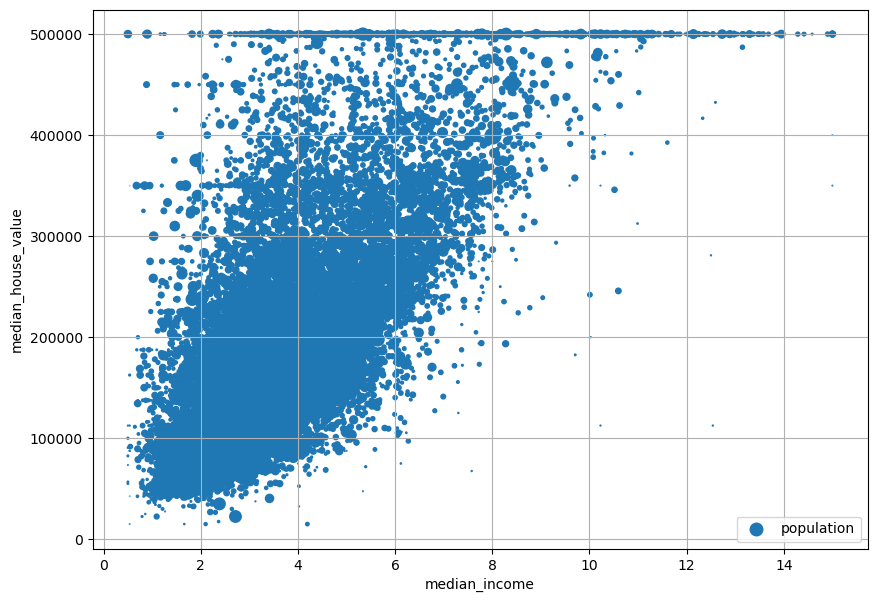

In [ ]:
# from housing.corr() we saw median_income and median_house_value has strong correlation 0.688. This diagram prove that strong correlation visually.
housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    grid=True,
    s=housing["population"] / 100,
    label="population",
    legend=True,
    sharex=False,
    figsize=(10, 7)
)

plt.show()

# Prepare Data for ML Algorithm

In [21]:
# Separte into housing input and housing label (target)
housing = strat_train_set.drop("median_house_value", axis=1)  
housing_labels = strat_train_set["median_house_value"].copy()

## Data Cleaning
Most Machine Learning algorithms cannot work with missing features, we have 3 option to take care of this:-

1. Remove the district missing the feature
2. Remove the feature column
3. Fill the missing feature with somethng (0, mean, median) called imputation. we go with this option since it is least destructive of the other options.

In [ ]:
# housing.dropna(subset=["total_bedrooms"], inplace=True)  # option 1
# housing.drop("total_bedrooms", axis=1)  # option 2
median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)


In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)
housing_num = imputer.transform(housing_num)
imputer.statistics_


array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [30]:
housing_num = pd.DataFrame(
    housing_num,
    columns=housing.select_dtypes(include=[np.number]).columns
)

housing_num.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,537.881298,1425.513929,499.990189,3.870428
std,2.000624,2.133294,12.585738,2185.287466,421.831667,1094.795467,382.865787,1.891936
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.800000,33.930000,18.000000,1447.000000,297.000000,787.000000,279.000000,2.562500
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500
75%,-118.010000,37.720000,37.000000,3154.000000,642.000000,1726.000000,603.000000,4.750000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100
